In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
import math  
import sklearn.metrics 
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Resumen

1. Crear la matriz de usuarios/películas
2. Normalización de los datos
3. Crear la matriz de similitud
4. KN-Neighbours
5. Mejor K y distancia para KN-Neighbours
6. Accuracy Promedio
7. Predicciones

## 1. Crear la matriz usuarios/películas

In [2]:
df = pd.read_csv('BBDD_1M/ratings.dat', delimiter='::', engine='python', header=None, names=['userId', 'movieId', 'rating', 'timestamp'], encoding='ISO-8859-1')
df.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [3]:
indice=list(df['userId'].unique())
columnas=list(df['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
 
matriz_usuario_pelicula=pd.pivot_table(data=df,values='rating',index='userId',columns='movieId')
matriz_usuario_pelicula.head(10)

movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN


## 2. Normalización de los datos

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def normalizar_datos(matriz_usuario_pelicula):
    # Creamos una copia de la matriz para evitar modificar el original
    matriz_escasez_copy = matriz_usuario_pelicula.copy()
    
    # Inicializamos StandardScaler sin centrado en 0 debido a NaNs
    scaler = StandardScaler(with_mean=True, with_std=True)
    
    # Aplicamos la normalización solo en las columnas que tienen datos no NaN
    for user_id in matriz_escasez_copy.index:
        # Seleccionamos las calificaciones del usuario (excluyendo NaNs)
        user_ratings = matriz_escasez_copy.loc[user_id].dropna()
        if not user_ratings.empty:
            # Normalizamos las calificaciones de este usuario
            normalized_ratings = scaler.fit_transform(user_ratings.values.reshape(-1, 1)).flatten()
            # Colocamos los valores normalizados en la matriz original, manteniendo NaNs donde no hay calificaciones
            matriz_escasez_copy.loc[user_id, user_ratings.index] = normalized_ratings
    
    # Llenamos los NaNs con 0
    matriz_escasez_copy = matriz_escasez_copy.fillna(0)
    return matriz_escasez_copy



In [5]:
matriz_normalizada = normalizar_datos(matriz_usuario_pelicula)
matriz_normalizada.head(20)

movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,1.202827,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
5,0.000000,0.000000,0.0,0.000000,0.0,-1.014718,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
6,0.119523,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
7,0.000000,0.000000,0.0,0.000000,0.0,-0.438529,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
8,0.124848,0.000000,0.0,-0.959767,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
9,1.548952,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,-0.901629,0.0,0.0,0.0,0.0


También es necesario reescalar la predicción que se ha hecho, por tanto aplicamos el cálculo a la inversa, y además hacemos un .clip() para que las calificaciones no sean menores a 0.5 o mayores de 5

In [ ]:
def reescalar_predicciones(predicciones_normalizadas, matriz_usuario_pelicula, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar de cada usuario ignorando los NaNs originales
    medias_usuarios = matriz_usuario_pelicula.mean(axis=1, skipna=True)
    desviaciones_usuarios = matriz_usuario_pelicula.std(axis=1, skipna=True)
    
    # Aplicamos la transformación inversa sólo donde había datos originales
    predicciones_reescaladas = predicciones_normalizadas.mul(desviaciones_usuarios, axis=0).add(medias_usuarios, axis=0)
    predicciones_reescaladas = predicciones_reescaladas.where(~matriz_usuario_pelicula.isna(), np.nan)
    predicciones_reescaladas = predicciones_reescaladas.round()
    predicciones_reescaladas = predicciones_reescaladas.clip(lower=min_rating, upper=max_rating)
    
    return predicciones_reescaladas



Como se puede ver a continuacion la matriz obtenida es exactamente igual que la principal

In [7]:
predicciones_reescaladas = reescalar_predicciones(matriz_normalizada, matriz_usuario_pelicula)
predicciones_reescaladas.head(20)

movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN


## 5. Mejor K y distancia para K-Nearest Neighbours

In [ ]:
def peliculas_del_usuario(usuario, matriz_usuario_pelicula):
    # Filtramos las películas que no tienen valor NaN para el usuario
    usuario_data = matriz_usuario_pelicula.iloc[usuario].dropna()

    # Obtenemos las películas y sus valoraciones
    lista_peliculas = usuario_data.index.tolist()  # Películas votadas
    valoraciones_originales = usuario_data.values.tolist()  # Valoraciones correspondientes

    # print("ID's de películas votadas por el usuario: " + str(lista_peliculas[:10]) + "... (total: " + str(len(lista_peliculas)) + ")")
    # print("Valoraciones de las películas votadas por el usuario: " + str(valoraciones_originales[:10]) + "... (total: " + str(len(valoraciones_originales)) + ")")
    
    return lista_peliculas, valoraciones_originales


In [9]:
def peliculas_con_minimo_vecinos(lista_peliculas_usuario, valoraciones_peliculas, matriz_normalizada, vecinos_min):
    # Filtramos solo las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_filtradas = []
    valoraciones_filtradas = []
    
    for i, pelicula in enumerate(lista_peliculas_usuario):
        # Asegurarse de que 'pelicula' es el identificador correcto que corresponde a las columnas de usuario_pelicula
        if pelicula not in matriz_normalizada.columns:
            print(f"Película {pelicula} no encontrada en las columnas.")
            continue
        
        # Seleccionamos los usuarios que vieron la película, es decir, aquellos con valoraciones != 0
        usuarios_que_vieron_la_pelicula = matriz_normalizada[matriz_normalizada[pelicula].notna() & (matriz_normalizada[pelicula] != 0)][pelicula]
        
        # Si el número de usuarios que vieron la película es mayor o igual a 'vecinos_min', la añadimos a la lista
        if len(usuarios_que_vieron_la_pelicula) >= vecinos_min:
            peliculas_filtradas.append(pelicula)
            valoraciones_filtradas.append(valoraciones_peliculas[i])  # Añadimos la valoración correspondiente

    return peliculas_filtradas, valoraciones_filtradas


In [ ]:
def reescalar_prediccion(prediccion_normalizada, id_usuario, matriz_usuario_pelicula, min_rating=1, max_rating=5.0):
    # Calculamos la media y desviación estándar del usuario específico
    media_usuario = matriz_usuario_pelicula.loc[id_usuario].mean(skipna=True)
    desviacion_usuario = matriz_usuario_pelicula.loc[id_usuario].std(skipna=True)
    
    # Si la desviación estándar es válida, aplicamos el reescalado
    if not pd.isna(media_usuario) and not pd.isna(desviacion_usuario):
        prediccion_reescalada = (prediccion_normalizada * desviacion_usuario) + media_usuario
        # Clipping para mantener la predicción dentro del rango y redondeo
        prediccion_reescalada = np.clip(round(prediccion_reescalada, 2), min_rating, max_rating)
    else:
        prediccion_reescalada = np.nan
    
    return prediccion_reescalada

def similitud_distancias(lista_peliculas_usuario, usuario, distancia_escogida, vecinos, minkowski=False, reescalar=False):
    lista_similitud = []
    usuario_objetivo = matriz_normalizada.iloc[[usuario]]  # Datos del usuario objetivo
    
    # Recorrer las películas votadas por el usuario
    for pelicula in lista_peliculas_usuario:
        # Seleccionamos las valoraciones de los usuarios que han visto la película y que no tienen valoraciones nulas o 0
        usuarios_que_vieron_la_pelicula_con_nulls = matriz_normalizada[pelicula]
        usuarios_que_vieron_la_pelicula = matriz_normalizada[usuarios_que_vieron_la_pelicula_con_nulls.notna() & (usuarios_que_vieron_la_pelicula_con_nulls != 0)]
        usuarios_que_vieron_la_pelicula_con_nulls = usuarios_que_vieron_la_pelicula_con_nulls.loc[usuarios_que_vieron_la_pelicula.index]

        usuarios_que_vieron_la_pelicula = usuarios_que_vieron_la_pelicula.drop(index=usuario+1, errors='ignore')
        usuarios_que_vieron_la_pelicula_con_nulls = usuarios_que_vieron_la_pelicula_con_nulls.drop(index=usuario+1, errors='ignore')

        knn = KNeighborsRegressor(metric=distancia_escogida, p=3 if minkowski else None, n_neighbors=vecinos)
        knn.fit(usuarios_que_vieron_la_pelicula, usuarios_que_vieron_la_pelicula_con_nulls) # Ajustar el modelo
        
        # Predecir para el usuario objetivo
        prediccion_usuario = knn.predict(usuario_objetivo)
        
        # Reescalar la predicción para que esté dentro del rango adecuado
        if reescalar:
            prediccion_usuario = reescalar_prediccion(prediccion_usuario[0],id_usuario, matriz_usuario_pelicula)
        
        lista_similitud.append(prediccion_usuario)  # Añadir la predicción reescalada a la lista de similitudes

    return lista_similitud

In [11]:
def mejor_cantidad_de_vecinos(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos, distancia_escogida, minkowski=False, reescalado=False):
    mejor_k = None
    mejor_error = float('inf')
    resultados_vecinos = []

    for k in range(2, min_vecinos):
        # Obtenemos las predicciones utilizando similitud_distancias
        similitud = similitud_distancias(lista_peliculas, usuario, distancia_escogida, k, minkowski, reescalado)
        
        # Calculamos el error con las valoraciones originales no normalizadas
        evaluacion = sklearn.metrics.mean_squared_error(valoraciones_peliculas, similitud)
        resultados_vecinos.append(evaluacion)
        
        print("Cuando usamos k= " + str(k) + " obtenemos " + str(evaluacion))
        
        if evaluacion < mejor_error:
            mejor_k = k
            mejor_error = evaluacion
    
    print("Mejor resultado obtenido con la distancia " + distancia_escogida + " es K = " + str(mejor_k))

    plt.plot(range(1, len(resultados_vecinos) + 1), resultados_vecinos)
    plt.xlabel('Número de vecinos (k)')
    plt.ylabel('Error (MSE)')
    plt.title(f'Evolución del MSE según k (Distancia: {distancia_escogida})')
    plt.show()

    return mejor_k,resultados_vecinos


Aqui utilizaremos un usuario con la misma cantidad de vecinos que en la base de datos de 100K, para tener resultados lo mas parecidos posibles, es decir las 50 primeras peliculas de un usuario con 216.

In [12]:
data_100K = pd.read_csv("BBDD_100K/ratings.csv")
user_3_ratings = data_100K[data_100K['userId'] == 4]

# Contar la cantidad de películas distintas valoradas por el usuario
num_movies_rated = user_3_ratings['movieId'].nunique()
print(f"El usuario con ID 3 ha valorado {num_movies_rated} películas diferentes.")

El usuario con ID 3 ha valorado 216 películas diferentes.


In [13]:
user_movie_counts = df.groupby('userId')['movieId'].nunique()

# Filtrar para encontrar usuarios con exactamente 216 películas valoradas
user_with_216_ratings = user_movie_counts[user_movie_counts == 216]
print(user_with_216_ratings)

userId
3665    216
5927    216
Name: movieId, dtype: int64


Usaremos el usuario 3665

In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial import distance_matrix
from scipy.spatial.distance import euclidean, pdist, squareform
from sklearn.model_selection import GridSearchCV, cross_val_score

In [15]:
id_usuario=3664 # 1 menos para la lista
min_vecinos = 20
# lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario,matriz_usuario_pelicula)
lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(id_usuario,matriz_normalizada)
lista_peliculas = lista_peliculas[0:50] #limitaremos a 50 las peliculas
valoraciones_peliculas = valoraciones_peliculas[0:50] #limitaremos a 50 las peliculas


In [16]:
# Obtener identificadores de películas
lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(lista_peliculas_usuario=lista_peliculas, valoraciones_peliculas=valoraciones_peliculas, matriz_normalizada=matriz_normalizada, vecinos_min=min_vecinos)
similitudes = similitud_distancias(lista_peliculas_usuario=lista_peliculas, usuario=id_usuario, distancia_escogida='euclidean', vecinos=min_vecinos)
print(similitudes)


[array([0.61393174]), array([-0.53145302]), array([-0.54062568]), array([-1.03863657]), array([-0.64724642]), array([0.21744967]), array([0.01216732]), array([-0.6265955]), array([-0.32738528]), array([-0.06914998]), array([-0.09808482]), array([-0.91900974]), array([-0.2681161]), array([0.0171008]), array([-0.82375948]), array([-0.07364536]), array([0.14805242]), array([-0.20701924]), array([-0.73490271]), array([-0.90924989]), array([-0.05758146]), array([-0.06781814]), array([-0.47236972]), array([0.13910513]), array([-0.62595159]), array([0.21807024]), array([-0.21191663]), array([0.32721175]), array([0.14152316]), array([0.2942454]), array([-0.39323267]), array([-0.04288746]), array([0.17099095]), array([-0.29102362]), array([-0.10807525]), array([-0.2333381]), array([-0.31897893]), array([0.22139409]), array([0.28690439]), array([-0.44421463]), array([0.11346827]), array([-0.37615905]), array([-0.57312907]), array([-0.52079082]), array([0.47816482]), array([-0.67213565]), array([

Ahora lo que voy a hacer es calcular la mejor K en todas las distancias posibles, la distancia que de menor error y con la K mas grande será la mas indicada para utilizarse

In [ ]:
def evaluar_todas_las_distancias(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos):
    distancias = ['euclidean', 'manhattan', 'cosine', 'jaccard', 'chebyshev', 'minkowski']
    errores_por_distancia = {}
    
    for distancia in distancias:
        print(f"\nEvaluando con la distancia: {distancia}")
        _, errores = mejor_cantidad_de_vecinos(usuario, lista_peliculas, valoraciones_peliculas, min_vecinos, distancia, minkowski=(distancia=='minkowski'),reescalado=False)
        errores_por_distancia[distancia] = errores
        
    return errores_por_distancia

def graficar_errores_por_distancia(errores_por_distancia):
    plt.figure(figsize=(10, 6))
    
    for distancia, errores in errores_por_distancia.items():
        # Asegúrate de que las dimensiones coincidan
        vecinos = range(1, len(errores) + 1)  # Genera x en función del tamaño de errores
        plt.plot(vecinos, errores, label=f'{distancia}')
    
    plt.xlabel('Número de vecinos (k)')
    plt.ylabel('Error (MSE)')
    plt.title('Comparación de MSE por diferentes distancias y número de vecinos (k)')
    plt.legend()
    plt.show()


Evaluando con la distancia: euclidean
Cuando usamos k= 2 obtenemos 0.8083673567166173
Cuando usamos k= 3 obtenemos 0.4986243680272453
Cuando usamos k= 4 obtenemos 0.44683561415373774
Cuando usamos k= 5 obtenemos 0.41219931523345094
Cuando usamos k= 6 obtenemos 0.3585274267103465
Cuando usamos k= 7 obtenemos 0.2987345768374467
Cuando usamos k= 8 obtenemos 0.2665943280533724
Cuando usamos k= 9 obtenemos 0.24963290225607562
Cuando usamos k= 10 obtenemos 0.22300204941023893
Cuando usamos k= 11 obtenemos 0.22132557536446285
Cuando usamos k= 12 obtenemos 0.20737421661095537
Cuando usamos k= 13 obtenemos 0.225810758465626
Cuando usamos k= 14 obtenemos 0.2276544469121592
Cuando usamos k= 15 obtenemos 0.20699278954428793
Cuando usamos k= 16 obtenemos 0.19985891976730788
Cuando usamos k= 17 obtenemos 0.19762880285646992
Cuando usamos k= 18 obtenemos 0.20314089183192174
Cuando usamos k= 19 obtenemos 0.1998789107646121
Mejor resultado obtenido con la distancia euclidean es K = 17


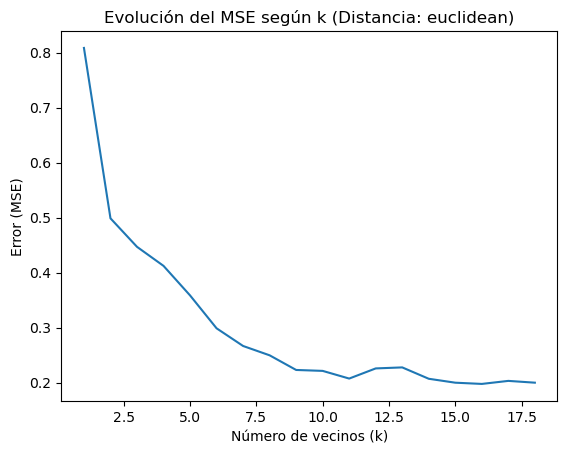


Evaluando con la distancia: manhattan
Cuando usamos k= 2 obtenemos 0.8592162249049887
Cuando usamos k= 3 obtenemos 0.6190061683497428
Cuando usamos k= 4 obtenemos 0.4590595344773029
Cuando usamos k= 5 obtenemos 0.39279929604481456
Cuando usamos k= 6 obtenemos 0.37467354978172157
Cuando usamos k= 7 obtenemos 0.33272188239295525
Cuando usamos k= 8 obtenemos 0.3213535953556086
Cuando usamos k= 9 obtenemos 0.274488035883044
Cuando usamos k= 10 obtenemos 0.26381544112461114
Cuando usamos k= 11 obtenemos 0.2422852634044789
Cuando usamos k= 12 obtenemos 0.2381241690808109
Cuando usamos k= 13 obtenemos 0.23913308340763853
Cuando usamos k= 14 obtenemos 0.22597898125294238
Cuando usamos k= 15 obtenemos 0.2133418335298156
Cuando usamos k= 16 obtenemos 0.20638938072824745
Cuando usamos k= 17 obtenemos 0.2072807981373356
Cuando usamos k= 18 obtenemos 0.19990574342517653
Cuando usamos k= 19 obtenemos 0.21460570827142736
Mejor resultado obtenido con la distancia manhattan es K = 18


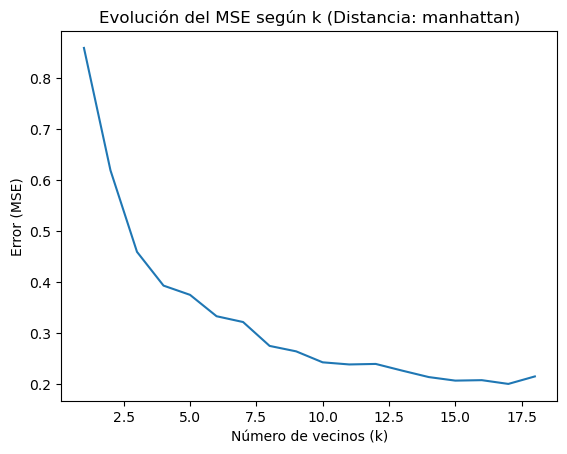


Evaluando con la distancia: cosine
Cuando usamos k= 2 obtenemos 0.5671768586120902
Cuando usamos k= 3 obtenemos 0.5131899928422593
Cuando usamos k= 4 obtenemos 0.45019524135338546
Cuando usamos k= 5 obtenemos 0.3909402911231383
Cuando usamos k= 6 obtenemos 0.40303295830637964
Cuando usamos k= 7 obtenemos 0.4076204993745713
Cuando usamos k= 8 obtenemos 0.3855338268218948
Cuando usamos k= 9 obtenemos 0.36016301144550633
Cuando usamos k= 10 obtenemos 0.3652441311880346
Cuando usamos k= 11 obtenemos 0.346160659843142
Cuando usamos k= 12 obtenemos 0.33236898357541794
Cuando usamos k= 13 obtenemos 0.3154741823713986
Cuando usamos k= 14 obtenemos 0.29785366454246287
Cuando usamos k= 15 obtenemos 0.2880293096163733
Cuando usamos k= 16 obtenemos 0.2794459193959393
Cuando usamos k= 17 obtenemos 0.26376231647603965
Cuando usamos k= 18 obtenemos 0.25270158295301787
Cuando usamos k= 19 obtenemos 0.24836942006367976
Mejor resultado obtenido con la distancia cosine es K = 19


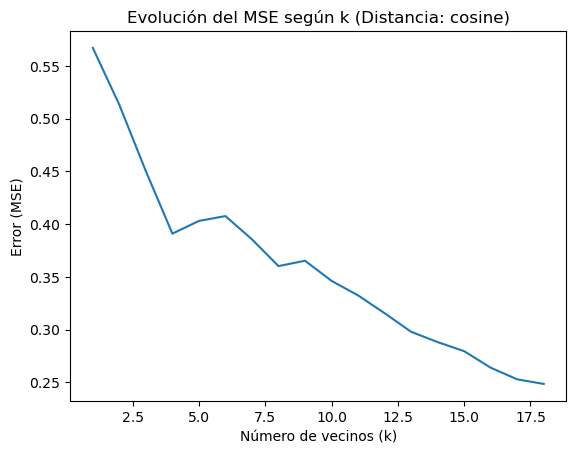


Evaluando con la distancia: jaccard
Cuando usamos k= 2 obtenemos 0.7047233925977734
Cuando usamos k= 3 obtenemos 0.6416938167088767
Cuando usamos k= 4 obtenemos 0.5125276404057176
Cuando usamos k= 5 obtenemos 0.4669184121176299
Cuando usamos k= 6 obtenemos 0.42143511240299003
Cuando usamos k= 7 obtenemos 0.44164438365135633
Cuando usamos k= 8 obtenemos 0.41569228270267017
Cuando usamos k= 9 obtenemos 0.4009610921828765
Cuando usamos k= 10 obtenemos 0.36103288284003976
Cuando usamos k= 11 obtenemos 0.35384351166603184
Cuando usamos k= 12 obtenemos 0.33431417743174086
Cuando usamos k= 13 obtenemos 0.3233034848365615
Cuando usamos k= 14 obtenemos 0.31794813867392213
Cuando usamos k= 15 obtenemos 0.31405045206621424
Cuando usamos k= 16 obtenemos 0.2919705022678158
Cuando usamos k= 17 obtenemos 0.26597673379339415
Cuando usamos k= 18 obtenemos 0.27214171925030645
Cuando usamos k= 19 obtenemos 0.266818890983128
Mejor resultado obtenido con la distancia jaccard es K = 17


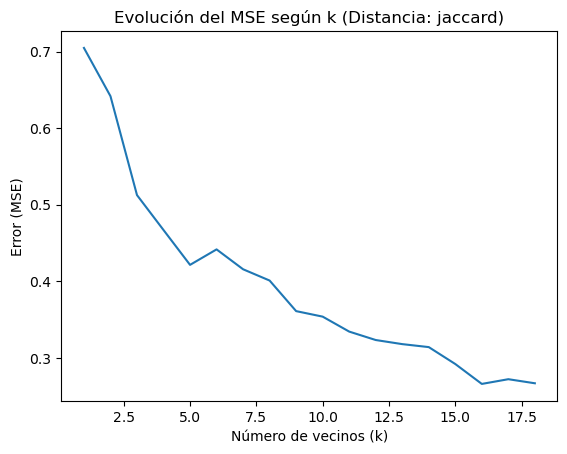


Evaluando con la distancia: chebyshev
Cuando usamos k= 2 obtenemos 0.5475054187498368
Cuando usamos k= 3 obtenemos 0.4035092858400939
Cuando usamos k= 4 obtenemos 0.27866828470331145
Cuando usamos k= 5 obtenemos 0.24677847794587993
Cuando usamos k= 6 obtenemos 0.21156320546704918
Cuando usamos k= 7 obtenemos 0.19385251287162494
Cuando usamos k= 8 obtenemos 0.21357847060068588
Cuando usamos k= 9 obtenemos 0.2058506573708815
Cuando usamos k= 10 obtenemos 0.18241990224829177
Cuando usamos k= 11 obtenemos 0.17620110848817463
Cuando usamos k= 12 obtenemos 0.17909450170545685
Cuando usamos k= 13 obtenemos 0.17589124002356815
Cuando usamos k= 14 obtenemos 0.17896850912086068
Cuando usamos k= 15 obtenemos 0.17377379037039561
Cuando usamos k= 16 obtenemos 0.17065674196662664
Cuando usamos k= 17 obtenemos 0.16965502055476386
Cuando usamos k= 18 obtenemos 0.16436923576332374
Cuando usamos k= 19 obtenemos 0.1798847844701925
Mejor resultado obtenido con la distancia chebyshev es K = 18


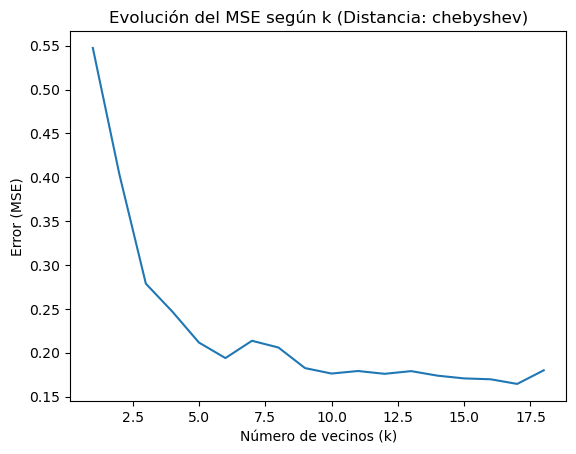


Evaluando con la distancia: minkowski
Cuando usamos k= 2 obtenemos 0.6657190347960735
Cuando usamos k= 3 obtenemos 0.5146414594988051
Cuando usamos k= 4 obtenemos 0.4269892308749772
Cuando usamos k= 5 obtenemos 0.3269041566712399
Cuando usamos k= 6 obtenemos 0.27898929731242283
Cuando usamos k= 7 obtenemos 0.27605715166333433
Cuando usamos k= 8 obtenemos 0.25859989474182504
Cuando usamos k= 9 obtenemos 0.25498662228863617
Cuando usamos k= 10 obtenemos 0.23907290930471903
Cuando usamos k= 11 obtenemos 0.21586933974744013
Cuando usamos k= 12 obtenemos 0.2092508519436452
Cuando usamos k= 13 obtenemos 0.21491256308068504
Cuando usamos k= 14 obtenemos 0.21386821679482546
Cuando usamos k= 15 obtenemos 0.19215885388110976
Cuando usamos k= 16 obtenemos 0.18452466541676005
Cuando usamos k= 17 obtenemos 0.19858857606618283
Cuando usamos k= 18 obtenemos 0.18702271195337952
Cuando usamos k= 19 obtenemos 0.1910095439640903
Mejor resultado obtenido con la distancia minkowski es K = 16


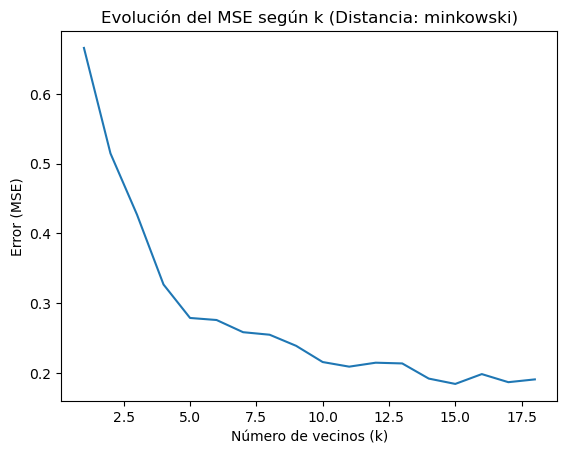

In [18]:
errores_por_distancia = evaluar_todas_las_distancias(usuario=id_usuario, lista_peliculas=lista_peliculas, valoraciones_peliculas=valoraciones_peliculas, min_vecinos=min_vecinos)

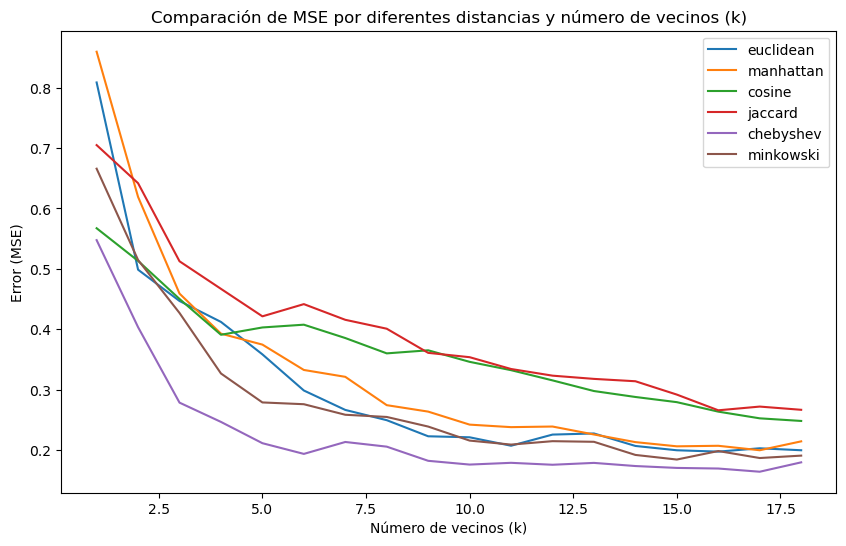

In [19]:
graficar_errores_por_distancia(errores_por_distancia=errores_por_distancia, min_vecinos=min_vecinos)

### Conclusión sobre la Elección de K Vecinos y Distancia

En el caso de la base de datos de 1M parece que la distancia de Chebyshev es bastante mejor que las demás, al final podemos apreciar como aumenta el error, pero como no vamos a utilizar tantos vecinos no nos dará problemas, la K escogida es 18.

En el hipotético caso de que quisieramos utilizar un número mucho mas grande de vecinos estoy seguro de que cosine daría mejores resultados.

### Ejecutar el codigo de cada algoritmo para las mejores K de cada algoritmo

In [20]:
usuario = 3664
minimo_vecinos = 20

# Obtener lista de películas y valoraciones
lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, matriz_usuario_pelicula)
lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
    lista_peliculas_usuario=lista_peliculas, 
    valoraciones_peliculas=valoraciones_peliculas, 
    matriz_normalizada=matriz_normalizada, 
    vecinos_min=minimo_vecinos
)

# Similitud Euclidean
similitud_euclideana = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='euclidean', 
    vecinos=17,
    reescalar=True
)
print("Similitud Euclidean:", similitud_euclideana)

# Similitud Manhattan
similitud_manhattan = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='manhattan', 
    vecinos=18,
    reescalar=True
)
print("Similitud Manhattan:", similitud_manhattan)

# Similitud Cosine
similitud_cosine = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='cosine', 
    vecinos=19,
    reescalar=True
)
print("Similitud Cosine:", similitud_cosine)

# Similitud Jaccard
similitud_jaccard = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='jaccard', 
    vecinos=17,
    reescalar=True
)
print("Similitud Jaccard:", similitud_jaccard)

# Similitud Chebyshev
similitud_chebyshev = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='chebyshev', 
    vecinos=18,
    reescalar=True
)
print("Similitud Chebyshev:", similitud_chebyshev)

# Similitud Minkowski
similitud_minkowski = similitud_distancias(
    lista_peliculas_usuario=lista_peliculas, 
    usuario=usuario, 
    distancia_escogida='minkowski', 
    vecinos=16,
    minkowski=True,
    reescalar=True
)
print("Similitud Minkowski:", similitud_minkowski)


Similitud Euclidean: [3.76, 2.91, 3.09, 3.87, 4.02, 3.5, 2.48, 3.39, 2.61, 2.17, 3.14, 2.83, 2.56, 3.11, 2.48, 2.64, 3.12, 3.52, 2.81, 2.75, 3.49, 2.91, 2.66, 2.96, 2.96, 2.64, 3.32, 2.97, 2.7, 2.62, 2.99, 2.71, 3.93, 3.04, 2.34, 3.82, 3.62, 3.82, 2.85, 3.67, 3.89, 3.27, 2.64, 2.91, 2.27, 2.66, 3.06, 2.89, 2.59, 3.58, 2.58, 3.21, 3.03, 2.54, 3.15, 3.34, 3.36, 1.99, 2.28, 2.88, 3.91, 2.68, 3.43, 4.06, 3.63, 3.1, 3.48, 3.86, 2.67, 3.32, 2.94, 3.17, 3.41, 3.19, 2.95, 2.89, 3.25, 3.21, 3.62, 3.77, 3.68, 3.3, 3.39, 3.64, 3.33, 3.57, 3.34, 3.7, 3.12, 3.4, 2.84, 3.14, 2.31, 2.72, 2.93, 2.49, 2.94, 2.67, 2.94, 3.2, 2.54, 2.88, 2.83, 3.58, 1.98, 2.36, 2.99, 2.31, 3.36, 3.04, 3.14, 3.76, 2.45, 3.21, 2.5, 3.52, 3.1, 3.25, 3.25, 2.89, 3.54, 3.31, 2.49, 2.64, 2.79, 2.72, 2.17, 2.57, 2.53, 3.74, 2.58, 2.8, 2.9, 3.06, 3.05, 2.68, 3.23, 2.86, 2.49, 2.71, 3.15, 2.63, 2.17, 3.4, 2.82, 2.63, 3.03, 3.0, 2.82, 2.89, 2.99, 2.63, 2.71, 3.34, 2.43, 2.82, 4.0, 2.47, 3.16, 2.45, 2.91, 1.64, 2.76, 3.07, 2.52, 2.

Ahora vamos a comparar cada una de las distancias con las valoraciones originales

In [21]:
def graficar_similitudes(valoraciones_peliculas, similitudes_dict, limit=25):
    plt.figure(figsize=(10, 6))
    # Graficar las valoraciones originales (limitadas a las primeras `limit` películas)
    plt.plot(valoraciones_peliculas[:limit], label="Valoraciones Originales", marker='o', linestyle='-', color='black')
    # Graficar las similitudes de cada distancia (limitadas a las primeras `limit` películas)
    for distancia, similitudes in similitudes_dict.items():
        plt.plot(similitudes[:limit], label=f"Similitud {distancia}", marker='o', linestyle='--')

    plt.xlabel('Películas')
    plt.ylabel('Valoración')
    plt.title(f'Similitudes por Distancia (Primeras {limit} Películas)')
    plt.legend()
    plt.show()

def calcular_mejor_distancia_global(valoraciones_peliculas, similitudes_dict):
    errores_totales = {}

    # Calcular el error total para cada distancia
    for distancia, similitudes in similitudes_dict.items():
        error_total = sum(abs(valoracion - similitudes[idx]) for idx, valoracion in enumerate(valoraciones_peliculas))
        errores_totales[distancia] = error_total

    # Seleccionar la distancia con el menor error total
    mejor_distancia_global = min(errores_totales, key=errores_totales.get)
    
    return mejor_distancia_global, errores_totales

def calcular_accuracy_promedio_por_distancia(valoraciones_peliculas, similitudes_dict):
    accuracies_porcentaje = {}

    # Calcular el accuracy promedio para cada distancia
    for distancia, similitudes in similitudes_dict.items():
        accuracies_individuales = []
        
        for valoracion, prediccion in zip(valoraciones_peliculas, similitudes):
            if valoracion != 0:  # Evitar divisiones por cero
                accuracy_individual = 1 - abs(valoracion - prediccion) / valoracion
                accuracies_individuales.append(accuracy_individual)
        
        # Calcular el promedio de los accuracies individuales para esta distancia
        accuracy_promedio = (sum(accuracies_individuales) / len(accuracies_individuales)) * 100 if accuracies_individuales else 0
        accuracies_porcentaje[distancia] = accuracy_promedio

    # Seleccionar la distancia con el mayor accuracy promedio
    mejor_distancia_global = max(accuracies_porcentaje, key=accuracies_porcentaje.get)

    # Comparar el accuracy promedio de cada distancia con el mejor (al final no lo uso)
    comparacion_accuracies = {}
    mejor_accuracy = accuracies_porcentaje[mejor_distancia_global]

    for distancia, accuracy in accuracies_porcentaje.items():
        comparacion_accuracies[distancia] = {
            "accuracy_promedio": accuracy,
            "comparado_con_mejor": (accuracy / mejor_accuracy) * 100
        }

    return mejor_distancia_global, comparacion_accuracies


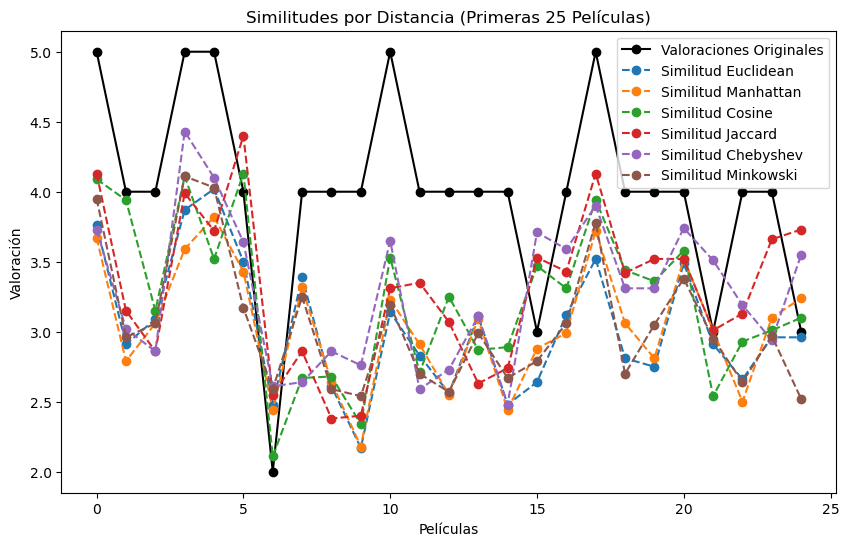

In [22]:
similitudes_dict = {
    "Euclidean": similitud_euclideana,
    "Manhattan": similitud_manhattan,
    "Cosine": similitud_cosine,
    "Jaccard": similitud_jaccard,
    "Chebyshev": similitud_chebyshev,
    "Minkowski": similitud_minkowski
}
graficar_similitudes(valoraciones_peliculas, similitudes_dict,limit=25)

In [23]:
mejor_distancia_global, comparacion_errores = calcular_accuracy_promedio_por_distancia(valoraciones_peliculas, similitudes_dict)

print(f"La mejor distancia global es {mejor_distancia_global}")
for distancia, datos in comparacion_errores.items():
    print(f"Distancia: {distancia}")
    print(f"  Accuracy Promedio: {datos['accuracy_promedio']:.2f}%")


La mejor distancia global es Cosine
Distancia: Euclidean
  Accuracy Promedio: 75.86%
Distancia: Manhattan
  Accuracy Promedio: 74.95%
Distancia: Cosine
  Accuracy Promedio: 78.74%
Distancia: Jaccard
  Accuracy Promedio: 75.34%
Distancia: Chebyshev
  Accuracy Promedio: 77.42%
Distancia: Minkowski
  Accuracy Promedio: 76.36%


## 6. Accuracy Promedio

In [24]:
def calcular_porcentaje_accuracy_promedio(valoraciones_peliculas, similitudes):
    # Calcular la precisión individual para cada valoración
    accuracies_individuales = [1 - abs(valoracion - prediccion) / valoracion if valoracion != 0 else 0
        for valoracion, prediccion in zip(valoraciones_peliculas, similitudes)
    ]
    
    accuracy_promedio = sum(accuracies_individuales) / len(accuracies_individuales) * 100 if accuracies_individuales else 0
    
    return accuracy_promedio


Para el accuracy final haré la estimación con la misma cantidad de usuarios que en la base de datos de 100K, por supuesto no se estarán evaluando 100K de valoraciones, esto varia de cada pelicula, pero en principio deberian ser muchas mas, y por tanto obtener un accuracy mejor

In [25]:
def total_accuracy(n_usuarios):
    minimo_vecinos = 20
    mejores_vecinos = 18
    lista_usuarios = list(df['userId'].unique())[0:(n_usuarios-1)]
    usuarios_vistos = 0
    sum_accuracys = 0 
    for usuario in lista_usuarios:
        print("Usuario nº: " + str(usuario))
        usuarios_vistos += 1
        lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, matriz_usuario_pelicula)
        lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
            lista_peliculas_usuario=lista_peliculas, 
            valoraciones_peliculas=valoraciones_peliculas, 
            matriz_normalizada=matriz_normalizada, 
            vecinos_min=minimo_vecinos
        )
        similitud_cosine = similitud_distancias(
            lista_peliculas_usuario=lista_peliculas, 
            usuario=usuario, 
            distancia_escogida='chebyshev', 
            vecinos=mejores_vecinos,
            reescalar=True
        )
        
        accuracy_promedio = calcular_porcentaje_accuracy_promedio(valoraciones_peliculas, similitud_cosine) # Calcular accuracy promedio como un valor escalar
        sum_accuracys += accuracy_promedio  

    print(f"Accuracy promedio: {sum_accuracys / usuarios_vistos:.2f}%")


n_usuarios = 609
total_accuracy(n_usuarios = n_usuarios)




Usuario nº: 1
Usuario nº: 2
Usuario nº: 3
Usuario nº: 4
Usuario nº: 5
Usuario nº: 6
Usuario nº: 7
Usuario nº: 8
Usuario nº: 9
Usuario nº: 10
Usuario nº: 11
Usuario nº: 12
Usuario nº: 13
Usuario nº: 14
Usuario nº: 15
Usuario nº: 16
Usuario nº: 17
Usuario nº: 18
Usuario nº: 19
Usuario nº: 20
Usuario nº: 21
Usuario nº: 22
Usuario nº: 23
Usuario nº: 24
Usuario nº: 25
Usuario nº: 26
Usuario nº: 27
Usuario nº: 28
Usuario nº: 29
Usuario nº: 30
Usuario nº: 31
Usuario nº: 32
Usuario nº: 33
Usuario nº: 34
Usuario nº: 35
Usuario nº: 36
Usuario nº: 37
Usuario nº: 38
Usuario nº: 39
Usuario nº: 40
Usuario nº: 41
Usuario nº: 42
Usuario nº: 43
Usuario nº: 44
Usuario nº: 45
Usuario nº: 46
Usuario nº: 47
Usuario nº: 48
Usuario nº: 49
Usuario nº: 50
Usuario nº: 51
Usuario nº: 52
Usuario nº: 53
Usuario nº: 54
Usuario nº: 55
Usuario nº: 56
Usuario nº: 57
Usuario nº: 58
Usuario nº: 59
Usuario nº: 60
Usuario nº: 61
Usuario nº: 62
Usuario nº: 63
Usuario nº: 64
Usuario nº: 65
Usuario nº: 66
Usuario nº: 67
Usua

In [26]:
def total_accuracy(n_usuarios):
    minimo_vecinos = 20
    mejores_vecinos = 19
    lista_usuarios = list(df['userId'].unique())[0:(n_usuarios-1)]
    usuarios_vistos = 0
    sum_accuracys = 0 
    for usuario in lista_usuarios:
        print("Usuario nº: " + str(usuario))
        usuarios_vistos += 1
        lista_peliculas, valoraciones_peliculas = peliculas_del_usuario(usuario, matriz_usuario_pelicula)
        lista_peliculas, valoraciones_peliculas = peliculas_con_minimo_vecinos(
            lista_peliculas_usuario=lista_peliculas, 
            valoraciones_peliculas=valoraciones_peliculas, 
            matriz_normalizada=matriz_normalizada, 
            vecinos_min=minimo_vecinos
        )
        similitud_cosine = similitud_distancias(
            lista_peliculas_usuario=lista_peliculas, 
            usuario=usuario, 
            distancia_escogida='cosine', 
            vecinos=mejores_vecinos,
            reescalar=True
        )
        
        accuracy_promedio = calcular_porcentaje_accuracy_promedio(valoraciones_peliculas, similitud_cosine) # Calcular accuracy promedio como un valor escalar
        sum_accuracys += accuracy_promedio  

    print(f"Accuracy promedio: {sum_accuracys / usuarios_vistos:.2f}%")


n_usuarios = 609
total_accuracy(n_usuarios = n_usuarios)




Usuario nº: 1
Usuario nº: 2
Usuario nº: 3
Usuario nº: 4
Usuario nº: 5
Usuario nº: 6
Usuario nº: 7
Usuario nº: 8
Usuario nº: 9
Usuario nº: 10
Usuario nº: 11
Usuario nº: 12
Usuario nº: 13
Usuario nº: 14
Usuario nº: 15
Usuario nº: 16
Usuario nº: 17
Usuario nº: 18
Usuario nº: 19
Usuario nº: 20
Usuario nº: 21
Usuario nº: 22
Usuario nº: 23
Usuario nº: 24
Usuario nº: 25
Usuario nº: 26
Usuario nº: 27
Usuario nº: 28
Usuario nº: 29
Usuario nº: 30
Usuario nº: 31
Usuario nº: 32
Usuario nº: 33
Usuario nº: 34
Usuario nº: 35
Usuario nº: 36
Usuario nº: 37
Usuario nº: 38
Usuario nº: 39
Usuario nº: 40
Usuario nº: 41
Usuario nº: 42
Usuario nº: 43
Usuario nº: 44
Usuario nº: 45
Usuario nº: 46
Usuario nº: 47
Usuario nº: 48
Usuario nº: 49
Usuario nº: 50
Usuario nº: 51
Usuario nº: 52
Usuario nº: 53
Usuario nº: 54
Usuario nº: 55
Usuario nº: 56
Usuario nº: 57
Usuario nº: 58
Usuario nº: 59
Usuario nº: 60
Usuario nº: 61
Usuario nº: 62
Usuario nº: 63
Usuario nº: 64
Usuario nº: 65
Usuario nº: 66
Usuario nº: 67
Usua

## 7. Predicciones

Ahora que ya sabemos que distancia y que K nos corresponde podemos hacer la prediccion para el usuario que deseemos, esta predicción nos devolverá las 10 mejores predicciones del usuario, las cuales se le recomendarían

In [27]:
import pandas as pd

# Cargar los archivos CSV proporcionados
movies = pd.read_csv('BBDD_1M/movies.dat', delimiter='::', engine='python', header=None, names=['movieId', 'title', 'genres'], encoding='ISO-8859-1')
ratings = pd.read_csv('BBDD_1M/ratings.dat', delimiter='::', engine='python', header=None, names=['userId', 'movieId', 'rating', 'timestamp'], encoding='ISO-8859-1')
# Mostrar una muestra de los datos para asegurarnos de que se han cargado correctamente
print(movies.head())
print(ratings.head())


   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy
   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291


In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

def peliculas_no_valoradas(usuario, matriz_usuario_pelicula):    
    peliculas_no_votadas = matriz_usuario_pelicula.loc[usuario][matriz_usuario_pelicula.loc[usuario].isna()].index.tolist() # Filtrar las películas que el usuario no ha valorado (NaN en la matriz de matriz_usuario_pelicula)
    
    return peliculas_no_votadas

def peliculas_con_minimo_vecinos(lista_peliculas_usuario, usuario_pelicula, vecinos_min):
    # Filtramos solo las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_filtradas = []

    for pelicula in lista_peliculas_usuario:
        # Asegurarse de que 'pelicula' es el identificador correcto que corresponde a las columnas de usuario_pelicula
        if pelicula not in usuario_pelicula.columns:
            continue
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuario_pelicula[pelicula].notna() & (usuario_pelicula[pelicula] != 0)][pelicula]  # Seleccionamos los usuarios que vieron la película
        
        # Si el número de usuarios que vieron la película es mayor o igual a 'vecinos_min', la añadimos a la lista
        if len(usuarios_que_vieron_la_pelicula) >= vecinos_min:
            peliculas_filtradas.append(pelicula)

    return peliculas_filtradas

def reescalar_prediccion(prediccion_normalizada, id_usuario, matriz_usuario_pelicula, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar del usuario específico
    media_usuario = matriz_usuario_pelicula.loc[id_usuario].mean(skipna=True)
    desviacion_usuario = matriz_usuario_pelicula.loc[id_usuario].std(skipna=True)
    
    # Si la desviación estándar es válida, aplicamos el reescalado
    if not pd.isna(media_usuario) and not pd.isna(desviacion_usuario):
        prediccion_reescalada = (prediccion_normalizada * desviacion_usuario) + media_usuario
        prediccion_reescalada = np.clip(round(prediccion_reescalada, 2), min_rating, max_rating) # Clipping para mantener la predicción dentro del rango y redondeo
    else:
        prediccion_reescalada = np.nan
    
    return prediccion_reescalada

def recomendar_peliculas(usuario, matriz_usuario_pelicula, usuario_pelicula, movies,mejores_vecinos, distancia_escogida='manhattan', vecinos=20, top_n=10, limite_peliculas_no_votadas=100):
   
    # Obtener las películas que el usuario no ha valorado
    peliculas_no_votadas = peliculas_no_valoradas(usuario, matriz_usuario_pelicula)
    
    # Limitar el número de películas no votadas que vamos a evaluar
    if len(peliculas_no_votadas) > limite_peliculas_no_votadas:
        peliculas_no_votadas = np.random.choice(peliculas_no_votadas, limite_peliculas_no_votadas, replace=False)
    
    # Filtrar las películas con al menos 'vecinos_min' valoraciones distintas de 0
    peliculas_no_votadas = peliculas_con_minimo_vecinos(peliculas_no_votadas, usuario_pelicula, vecinos_min=vecinos)
    
    # Predecir las valoraciones para las películas no votadas
    predicciones = []
    for pelicula in peliculas_no_votadas:
        # Seleccionamos los usuarios que han valorado la película
        usuarios_que_vieron_la_pelicula = usuario_pelicula[usuario_pelicula[pelicula].notna() & (usuario_pelicula[pelicula] != 0)]
        
        if usuarios_que_vieron_la_pelicula.empty:
            continue  # Saltar si no hay usuarios con valoraciones para esta película
        
        # Datos del usuario objetivo para la predicción
        usuario_objetivo = usuario_pelicula.iloc[[usuario]]

        # Reemplazar NaNs con ceros en los datos de entrada para evitar errores
        usuarios_que_vieron_la_pelicula = usuarios_que_vieron_la_pelicula.fillna(0)
        usuario_objetivo = usuario_objetivo.fillna(0)

        usuarios_que_vieron_la_pelicula = usuarios_que_vieron_la_pelicula.drop(index=usuario+1, errors='ignore')
        # Modelo KNN para la predicción
        knn = KNeighborsRegressor(metric=distancia_escogida, n_neighbors=mejores_vecinos)
        knn.fit(usuarios_que_vieron_la_pelicula, usuario_pelicula.loc[usuarios_que_vieron_la_pelicula.index, pelicula])
        
        # Predecir la valoración del usuario para la película
        prediccion_usuario = knn.predict(usuario_objetivo)[0]
        prediccion_reescalada = reescalar_prediccion(prediccion_usuario, usuario, matriz_usuario_pelicula)
        
        # Guardar la predicción con el ID de la película
        predicciones.append((pelicula, prediccion_reescalada))
    
    predicciones.sort(key=lambda x: x[1], reverse=True)

    mejores_peliculas = predicciones[:top_n]
    recomendaciones = pd.DataFrame(mejores_peliculas, columns=['movieId', 'Predicted Rating']).merge(movies, on='movieId')
    
    return recomendaciones[['title', 'Predicted Rating', 'genres']]


In [29]:
usuario_id = 6
mejores_vecinos_cosine = 18
min_vecinos = 20

In [30]:
recomendaciones = recomendar_peliculas(usuario_id, matriz_usuario_pelicula, matriz_normalizada, movies,mejores_vecinos_cosine, distancia_escogida='cosine', vecinos=min_vecinos, top_n=10)

recomendaciones.head(10)

,title,Predicted Rating,genres
0,For All Mankind (1989),4.78,Documentary
1,"Hunt for Red October, The (1990)",4.73,Action|Thriller
2,Creature Comforts (1990),4.59,Animation|Comedy
3,Schindler's List (1993),4.52,Drama|War
4,"Killing, The (1956)",4.52,Crime|Film-Noir
5,"Shining, The (1980)",4.47,Horror
6,City Lights (1931),4.39,Comedy|Drama|Romance
7,No Way Out (1987),4.39,Thriller
8,"Third Man, The (1949)",4.35,Mystery|Thriller
9,Remember the Titans (2000),4.28,Drama


Tambien podemos buscar al usuario con la media de valoraciones mas baja posible, para ver si las predicciones se hacen entorno a esos valores.

En el siguiente ejemplo podemos ver como el usuario 442 tiene una media de 1.275, y las valoraciones se hacen entorno a esos datos

In [ ]:
# Encontrar al usuario con la media de valoraciones más baja
def usuario_media_mas_baja(matriz_usuario_pelicula):
    # Calcular la media de valoraciones de cada usuario, ignorando los NaN
    medias_usuarios = matriz_usuario_pelicula.mean(axis=1, skipna=True)
    
    # Encontrar el usuario con la media más baja
    usuario_min_media = medias_usuarios.idxmin()
    media_min = medias_usuarios.min()
    
    print(f"Usuario con la media más baja: {usuario_min_media}")
    print(f"Media de valoraciones del usuario: {media_min}")
    
    return usuario_min_media

# Ejemplo de ejecución para encontrar al usuario con la media más baja
usuario_con_media_baja = usuario_media_mas_baja(matriz_usuario_pelicula)


Usuario con la media más baja: 3598
Media de valoraciones del usuario: 1.0153846153846153


In [32]:
usuario_id = usuario_con_media_baja
recomendaciones = recomendar_peliculas(usuario_id, matriz_usuario_pelicula, matriz_normalizada, movies,mejores_vecinos_cosine, distancia_escogida='cosine', vecinos=min_vecinos, top_n=10)

recomendaciones.head(10)

,title,Predicted Rating,genres
0,"Close Shave, A (1995)",1.13,Animation|Comedy|Thriller
1,"Celebration, The (Festen) (1998)",1.09,Drama
2,Batman: Mask of the Phantasm (1993),1.09,Animation|Children's
3,Key Largo (1948),1.09,Crime|Drama|Film-Noir|Thriller
4,Ghost in the Shell (Kokaku kidotai) (1995),1.08,Animation|Sci-Fi
5,One Magic Christmas (1985),1.08,Drama|Fantasy
6,Apocalypse Now (1979),1.08,Drama|War
7,Butch Cassidy and the Sundance Kid (1969),1.08,Action|Comedy|Western
8,Primal Fear (1996),1.08,Drama|Thriller
9,Charade (1963),1.07,Comedy|Mystery|Romance|Thriller


También podemos ver que usuario es el que mas se parece a otro usuario, esto lo haremos con el coeficiente de pearson

In [33]:
usuario_id = 3
def usuario_mas_similar(usuario_id, matriz_usuario_pelicula, min_peliculas_comunes=5):
    valoraciones_usuario = matriz_usuario_pelicula.loc[usuario_id]
    
    correlaciones = matriz_usuario_pelicula.corrwith(valoraciones_usuario, axis=1, method='pearson')
    correlaciones = correlaciones.drop(index=usuario_id)
    
    peliculas_comunes = matriz_usuario_pelicula.notna().multiply(valoraciones_usuario.notna(), axis=0).sum(axis=1)

    correlaciones = correlaciones[peliculas_comunes >= min_peliculas_comunes]
    correlaciones = correlaciones[correlaciones < 1]
    
    usuario_mas_similar = correlaciones.idxmax()
    coeficiente_correlacion = correlaciones.max()
    
    return usuario_mas_similar, coeficiente_correlacion

usuario_similar, correlacion = usuario_mas_similar(usuario_id, matriz_usuario_pelicula)
print(f"El usuario más similar al usuario {usuario_id} es {usuario_similar} con un coeficiente de correlación de Pearson de {correlacion:.2f}.")



El usuario más similar al usuario 3 es 1049 con un coeficiente de correlación de Pearson de 1.00.
